# AI2008 - Group 7 - AI-Driven Dynamic Pricing in Freight & Shipping Logistics

## 0. Cài đặt môi trường

Trong dự án nghiên cứu về **AI-Driven Dynamic Pricing in Freight & Shipping Logistics**, nhóm đã thiết lập các thư viện sau:

1.  **Pandas**: Dùng để cấu trúc hóa dữ liệu từ file .csv thành DataFrame và thực hiện các thao tác biến đổi dữ liệu.
2.  **NumPy**: Hỗ trợ tính toán ma trận và các hàm toán học phức tạp cho thuật toán định giá.
3.  **SQLite3**: Quản trị cơ sở dữ liệu quan hệ tích hợp sẵn trong Python, giúp lưu trữ và truy vấn dữ liệu.
4.  **Matplotlib/Seaborn**: Hỗ trợ trực quan hóa các xu hướng giá.

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra phiên bản các thư viện chính
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"SQLite3 version: {sqlite3.sqlite_version}")

# Khởi tạo kết nối SQLite (tạo file database local)
conn = sqlite3.connect('freight_pricing_research.db')

print("\n--- Môi trường đã được cài đặt thành công ---")

Pandas version: 3.0.3
NumPy version: 2.5.0
SQLite3 version: 3.50.4

--- Môi trường đã được cài đặt thành công ---


## 1. Nhập và Kiểm tra Dataset (Dataset Loading & Exploration)

Trong phần này, nhóm sẽ thực hiện các bước sau:
1. Tải tập dữ liệu nghiên cứu từ file CSV (`DataCoSupplyChainDataset.csv`) - chương trình sẽ tự detect xem dataset có tồn tại trong file path được lưu trên Google Drive hay không - hoặc dataset có được tải lên trên đây hay không.
2. Chuyển đổi dữ liệu vào Pandas DataFrame để dễ dàng thao tác.
3. Xem trước 5 dòng đầu tiên để hiểu cấu trúc các cột như `Shipping Mode`, `Sales`, `Order Region`, và `Delivery Status`.

In [1]:
import os
import pandas as pd

# Tạo thư mục lưu trữ biểu đồ nếu chưa tồn tại
os.makedirs('charts_img', exist_ok=True)

# Tên file dataset
filename = 'DataCoSupplyChainDataset.csv'

# Kiểm tra file ở thư mục hiện tại trước, sau đó mới đến Google Drive
if os.path.exists(filename):
    file_path = filename
    print(f"Use as local: {file_path}")
else:
    file_path = filename # Đường dẫn local
    print("Error: Can not find dataset file. Please upload file to Colab.")

# Tiến hành đọc file CSV (180519 dòng x 53 cột)
try:
    df = pd.read_csv(file_path, encoding='latin-1')
    display(df.head())
except Exception as e:
    print(f"Error when reading CSV file: {e}")

Use as local: DataCoSupplyChainDataset.csv


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 2. DATA ANALYSIS WITH SQL & PYTHON with 3 Research Questions

Tập trung giải quyết 3 Research Questions:

**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*



### 2.1. Đưa dữ liệu từ DataFrame vào bảng SQLite để truy vấn.

In [9]:
# Re-establish connection as it might have been closed by previous cells
conn = sqlite3.connect('freight_pricing_research.db')

# Đưa dữ liệu vào SQLite table để thực hiện truy vấn
df.to_sql('supply_chain', conn, if_exists='replace', index=False)
print("Added data to 'supply_chain'.")

Added data to 'supply_chain'.


### 2.2. SQL Queries để giải quyết 3 RQ
**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*

In [10]:
# 1. [RQ1] Ảnh hưởng của thị trường và doanh số trung bình
query1 = """
SELECT
    Market,
    COUNT(*) as Total_Orders,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY Market
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query1, conn))

,Market,Total_Orders,Avg_Sales
0,Europe,50252,216.357494
1,Pacific Asia,41260,200.526993
2,LATAM,51594,199.201706
3,Africa,11614,197.559232
4,USCA,25799,196.384694


In [11]:
# 2. [RQ1] Tương quan giữa phương thức vận chuyển và doanh số
query2 = """
SELECT
    [Shipping Mode],
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query2, conn))

,Shipping Mode,Avg_Sales
0,Standard Class,204.380354
1,First Class,204.011281
2,Second Class,202.903363
3,Same Day,199.499698


In [12]:
# 3. [RQ2] Mối liên hệ giữa số lượng sản phẩm (Demand) và doanh số
query3 = """
SELECT
    [Order Item Quantity],
    AVG(Sales) as Avg_Sales
FROM supply_chain
WHERE [Order Item Quantity] > 1
GROUP BY [Order Item Quantity]
ORDER BY [Order Item Quantity]
LIMIT 10;
"""
display(pd.read_sql_query(query3, conn))

,Order Item Quantity,Avg_Sales
0,2,110.589542
1,3,166.691618
2,4,221.694599
3,5,277.391077


In [13]:
# 4. [RQ3] Tổng doanh thu theo phương thức vận chuyển
query4 = """
SELECT
    [Shipping Mode],
    SUM(Sales) as Total_Revenue
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Total_Revenue DESC;
"""
display(pd.read_sql_query(query4, conn))

,Shipping Mode,Total_Revenue
0,Standard Class,2.202239e+07
1,Second Class,7.145445e+06
2,First Class,5.674370e+06
3,Same Day,1.942529e+06


In [14]:
# 5. [RQ3] Lợi nhuận trung bình theo phân khúc khách hàng
query5 = """
SELECT
    [Customer Segment],
    AVG([Order Profit Per Order]) as Avg_Profit
FROM supply_chain
GROUP BY [Customer Segment]
ORDER BY Avg_Profit DESC;
"""
display(pd.read_sql_query(query5, conn))

,Customer Segment,Avg_Profit
0,Consumer,22.175390
1,Corporate,21.949204
2,Home Office,21.437359


In [15]:
# 6. [RQ2] Tìm mối tương quan giữa trạng thái giao hàng và doanh số
query6 = """
SELECT
    [Delivery Status],
    ROUND(AVG(Sales), 2) AS Avg_Sales
FROM supply_chain
GROUP BY [Delivery Status]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query6, conn))

,Delivery Status,Avg_Sales
0,Advance shipping,204.80
1,Shipping on time,204.06
2,Late delivery,203.34
3,Shipping canceled,202.52


In [16]:
# 7. [RQ2] Giá sản phẩm trung bình theo phương thức vận chuyển
query7 = """
SELECT
    [Shipping Mode],
    AVG([Order Item Product Price]) as Avg_Product_Price
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Product_Price DESC;
"""
display(pd.read_sql_query(query7, conn))

,Shipping Mode,Avg_Product_Price
0,Standard Class,141.904742
1,First Class,141.405508
2,Second Class,140.453302
3,Same Day,136.118171


In [17]:
# 8. [RQ1/RQ2] Thống kê ngày giao hàng thực tế theo phương thức vận chuyển
query8 = """
SELECT
    [Shipping Mode],
    AVG([Days for shipping (real)]) as Avg_Shipping_Days
FROM supply_chain
GROUP BY [Shipping Mode];
"""
display(pd.read_sql_query(query8, conn))

,Shipping Mode,Avg_Shipping_Days
0,First Class,2.000000
1,Same Day,0.478279
2,Second Class,3.990828
3,Standard Class,3.995907


In [18]:
# 9. [RQ3] Tổng số đơn hàng theo thị trường
query9 = """
SELECT
    Market,
    COUNT(*) as Total_Orders
FROM supply_chain
GROUP BY Market
ORDER BY Total_Orders DESC;
"""
display(pd.read_sql_query(query9, conn))

,Market,Total_Orders
0,LATAM,51594
1,Europe,50252
2,Pacific Asia,41260
3,USCA,25799
4,Africa,11614


In [19]:
# 10. [RQ1] Tỷ lệ rủi ro giao trễ theo thị trường
query10 = """
SELECT
    Market,
    AVG(CAST(Late_delivery_risk AS FLOAT)) as Late_Delivery_Rate
FROM supply_chain
GROUP BY Market
ORDER BY Late_Delivery_Rate DESC;
"""
display(pd.read_sql_query(query10, conn))

,Market,Late_Delivery_Rate
0,Europe,0.552078
1,Pacific Asia,0.550460
2,USCA,0.548006
3,Africa,0.545893
4,LATAM,0.543552


In [20]:
# 11. [RQ1] Phân tích doanh số theo mức chiết khấu
query11 = """
SELECT
    CASE
        WHEN [Order Item Discount Rate] < 0.05 THEN 'Low Discount'
        WHEN [Order Item Discount Rate] BETWEEN 0.05 AND 0.15 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS Discount_Level,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY Discount_Level;
"""
display(pd.read_sql_query(query11, conn))

,Discount_Level,Avg_Sales
0,High Discount,203.827159
1,Low Discount,203.715490
2,Medium Discount,203.765330


In [21]:
# 12. [RQ2] Tương quan giữa ngày vận chuyển và doanh số
query12 = """
SELECT
    [Days for shipping (real)] as Shipping_Days,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Days for shipping (real)]
ORDER BY Shipping_Days;
"""
display(pd.read_sql_query(query12, conn))

,Shipping_Days,Avg_Sales
0,0,202.032896
1,1,196.736407
2,2,204.400251
3,3,203.263487
4,4,204.259195
5,5,204.291286
6,6,203.498971


In [22]:
# 13. [RQ3] Phân tích doanh thu theo phân khúc khách hàng
query13 = """
SELECT
    [Customer Segment],
    SUM(Sales) AS Total_Revenue,
    COUNT(*) AS Order_Count,
    AVG(Sales) AS Avg_Per_Order
FROM supply_chain
GROUP BY [Customer Segment];
"""
display(pd.read_sql_query(query13, conn))

,Customer Segment,Total_Revenue,Order_Count,Avg_Per_Order
0,Consumer,1.909579e+07,93504,204.224313
1,Corporate,1.116841e+07,54789,203.843962
2,Home Office,6.520538e+06,32226,202.337802


In [23]:
# 14. [RQ1] Hiệu suất lợi nhuận trên mỗi đơn hàng theo phương thức vận chuyển
query14 = """
SELECT
    [Shipping Mode],
    AVG([Order Item Profit Ratio]) AS Avg_Profit_Ratio
FROM supply_chain
GROUP BY [Shipping Mode];
"""
display(pd.read_sql_query(query14, conn))

,Shipping Mode,Avg_Profit_Ratio
0,First Class,0.126486
1,Same Day,0.117568
2,Second Class,0.118427
3,Standard Class,0.120143


In [24]:
# 15. [RQ3] Thống kê theo thị trường và phương thức vận chuyển
query15 = """
SELECT
    Market,
    [Shipping Mode],
    COUNT(*) AS Sample_Size,
    AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY Market, [Shipping Mode]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query15, conn))

,Market,Shipping Mode,Sample_Size,Avg_Sales
0,Europe,Standard Class,29740,217.624071
1,Europe,First Class,7892,216.592194
2,Europe,Second Class,9861,214.256447
3,Europe,Same Day,2759,209.542766
4,Pacific Asia,First Class,6301,201.444140
5,Africa,Same Day,668,201.306815
6,Pacific Asia,Standard Class,24586,201.115619
7,Pacific Asia,Second Class,8147,200.130688
8,LATAM,First Class,7886,199.879694
9,LATAM,Standard Class,31119,199.344002


In [25]:
# 16. [RQ1] Tác động của rủi ro giao trễ lên doanh số
query16 = """
SELECT
    Late_delivery_risk,
    COUNT(*) AS Order_Count,
    AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY Late_delivery_risk
ORDER BY Late_delivery_risk;
"""
display(pd.read_sql_query(query16, conn))

,Late_delivery_risk,Order_Count,Avg_Sales
0,0,81542,204.291528
1,1,98977,203.344163


In [26]:
# 17. [RQ2] Top 10 danh mục sản phẩm có nhu cầu vận chuyển cao nhất
query17 = """
SELECT
    [Category Name],
    COUNT(*) as Total_Orders,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Category Name]
ORDER BY Total_Orders DESC
LIMIT 10;
"""
display(pd.read_sql_query(query17, conn))

,Category Name,Total_Orders,Avg_Sales
0,Cleats,24551,180.519848
1,Men's Footwear,22246,129.990005
2,Women's Apparel,21035,149.645828
3,Indoor/Outdoor Games,19298,149.704317
4,Fishing,17325,399.980011
5,Water Sports,15540,200.376106
6,Camping & Hiking,13729,299.980011
7,Cardio Equipment,12487,295.895187
8,Shop By Sport,10984,119.220870
9,Electronics,3156,117.564843


In [27]:
# 18. [RQ2] Chênh lệch ngày giao dự kiến vs thực tế theo phương thức vận chuyển
query18 = """
SELECT
   [Shipping Mode],
   AVG([Days for shipment (scheduled)] - [Days for shipping (real)]) AS Avg_Delay_Diff,
   AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Delay_Diff;
"""
display(pd.read_sql_query(query18, conn))

,Shipping Mode,Avg_Delay_Diff,Avg_Sales
0,Second Class,-1.990828,202.903363
1,First Class,-1.000000,204.011281
2,Same Day,-0.478279,199.499698
3,Standard Class,0.004093,204.380354


In [28]:
# 19. [RQ3] Top 5 thị trường có doanh thu cao nhất
query19 = """
SELECT
    Market,
    SUM(Sales) AS Total_Revenue
FROM supply_chain
GROUP BY Market
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
display(pd.read_sql_query(query19, conn))

,Market,Total_Revenue
0,Europe,1.087240e+07
1,LATAM,1.027761e+07
2,Pacific Asia,8.273744e+06
3,USCA,5.066529e+06
4,Africa,2.294453e+06


In [29]:
# 20. [RQ3] So sánh giá trị đơn hàng giữa các loại thanh toán
query20 = """
SELECT
    Type as Payment_Type,
    AVG(Sales) AS Avg_Sales,
    SUM(Sales) AS Total_Sales
FROM supply_chain
GROUP BY Type;
"""
display(pd.read_sql_query(query20, conn))

,Payment_Type,Avg_Sales,Total_Sales
0,CASH,205.068524,4.022624e+06
1,DEBIT,203.143916,1.407686e+07
2,PAYMENT,203.483552,8.490351e+06
3,TRANSFER,204.376280,1.019490e+07


## 3. EDA & Data Cleaning

Trong mục này, nhóm sẽ thực hiện phân tích chi tiết đặc điểm dữ liệu và xử lý dữ liệu để chuẩn bị cho việc xây dựng mô hình AI.

### 3.1. Exploratory Data Analysis (EDA)

In [29]:
# 1. Kiểm tra kích thước và kiểu dữ liệu
print("Shape of dataset:", df.shape)
print("\nData types:")
display(df.dtypes)

# 2. Kiểm tra tỷ lệ giá trị thiếu (Missing values %)
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values:")
display(missing_pct[missing_pct > 0])

# 3. Thống kê mô tả và phát hiện Outliers sơ bộ
display(df.describe())

Shape of dataset: (1000, 10)

Data types:


Number_of_Riders             int64
Number_of_Drivers            int64
Location_Category              str
Customer_Loyalty_Status        str
Number_of_Past_Rides         int64
Average_Ratings            float64
Time_of_Booking                str
Vehicle_Type                   str
Expected_Ride_Duration       int64
Historical_Cost_of_Ride    float64
dtype: object


Percentage of missing values:


Series([], dtype: float64)

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


### 3.2. Phát hiện Outliers
Kiểm tra các cột số quan trọng như `Sales`, `Benefit per order`, `Order Item Quantity` và `Product Price` để xem có giá trị ngoại lai hay không.

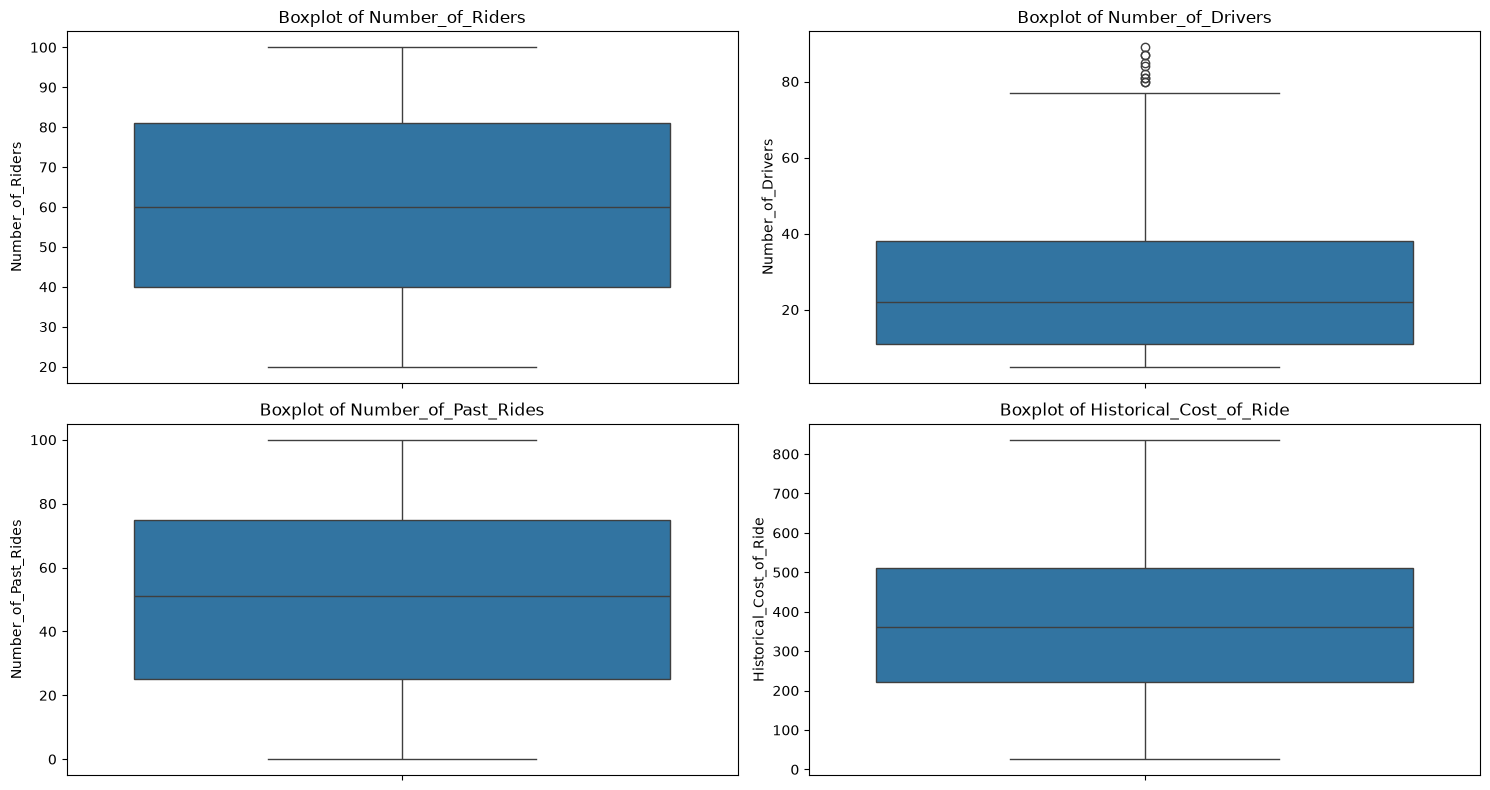

In [30]:
# 3.2. Phát hiện Outliers
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 3.3. Data Cleaning
Các bước thực hiện:
1. Xử lý giá trị trùng lặp (Duplicates).
2. Điền giá trị thiếu (Imputation) nếu có.
3. Mã hóa dữ liệu phân loại (Encoding Categorical Variables).

In [31]:
# 3.3. Data Cleaning
# 1. Loại bỏ các dòng trùng lặp
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Deleted {duplicate_count} duplicate row(s).")
else:
    print("No duplicate row.")

# 2. Xử lý missing values (nếu có)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3. Encoding (Cập nhật danh sách cột phân loại thực tế)
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Type', 'Delivery Status', 'Customer Segment', 'Market', 'Shipping Mode']
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[f'{col}_Encoded'] = le.fit_transform(df[col])

# 4. Lưu dữ liệu sạch vào database
conn = sqlite3.connect('freight_pricing_research.db')
df.to_sql('supply_chain', conn, if_exists='replace', index=False)
conn.close()

print("\n--- Cleaning successfully ---")

No duplicate row.

--- Cleaning successfully ---


### 3.4. EDA of Data Cleaning

**Correlation Matrix**

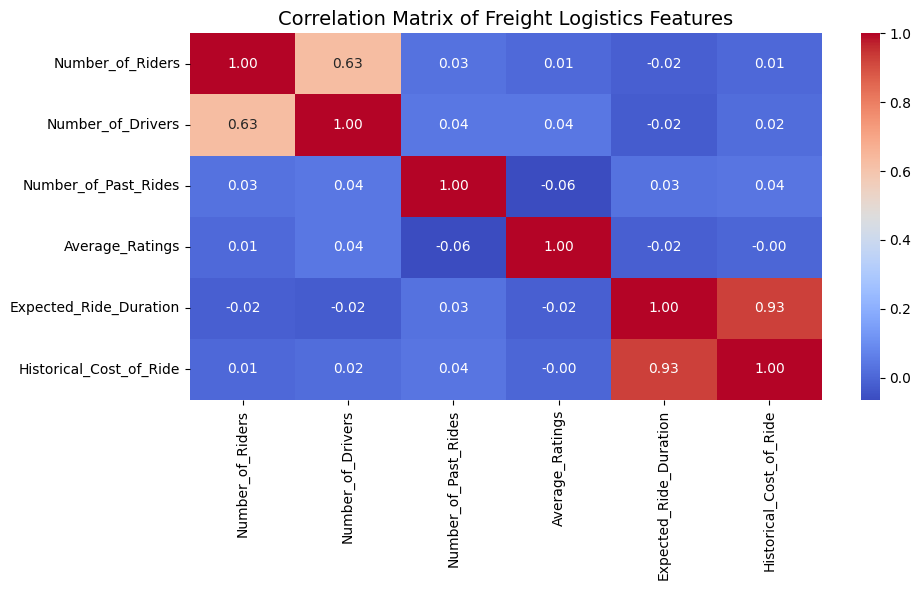

In [ ]:
# Market Variables & Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Connect to the database and fetch clean data
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# Plot the Correlation Matrix
plt.figure(figsize=(12, 8))
cols_to_corr = [
    'Sales', 'Benefit per order', 'Days for shipping (real)', 
    'Days for shipment (scheduled)', 'Order Item Quantity', 
    'Product Price', 'Late_delivery_risk', 
    'Type_Encoded', 'Delivery Status_Encoded', 
    'Customer Segment_Encoded', 'Market_Encoded', 'Shipping Mode_Encoded'
]
cols_to_corr = [c for c in cols_to_corr if c in df.columns]

sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Supply Chain Features', fontsize=14)
plt.tight_layout()
plt.savefig('charts_img/34_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**Outliers analysis**



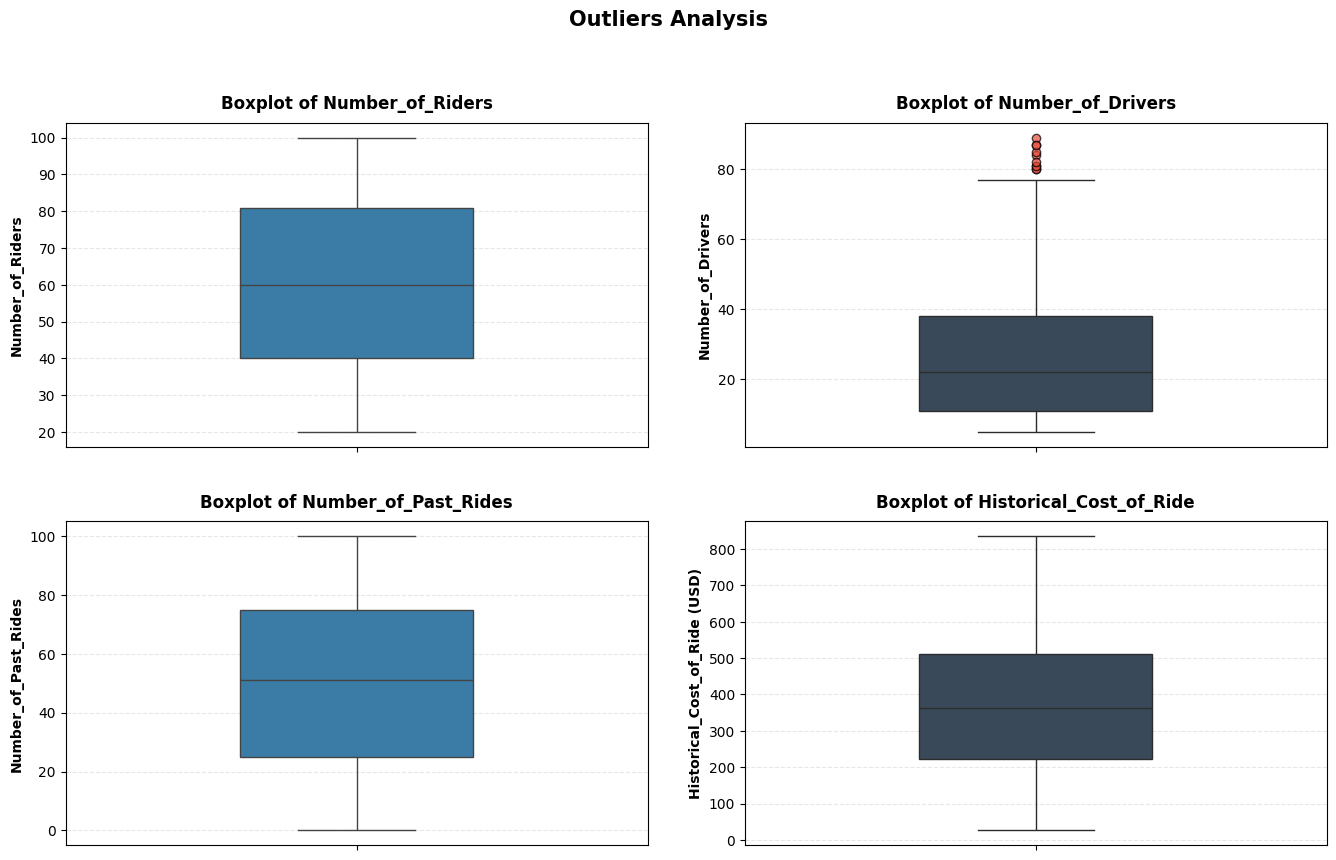

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel(col, fontsize=10, fontweight="bold")
    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Outliers Analysis', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(pad=3.0)
plt.savefig('charts_img/34_outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. DATA VISUALIZATION


Trong mục này, nhóm sẽ thực hiện phân tích các RQ thoả mãn các mục title, axis labels, 1–2 Insight (nhận xét)

**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*

### 4.1. [LINK TO RQ1] - Biểu đồ 1: Histogram - Khảo sát phân phối của biến chính

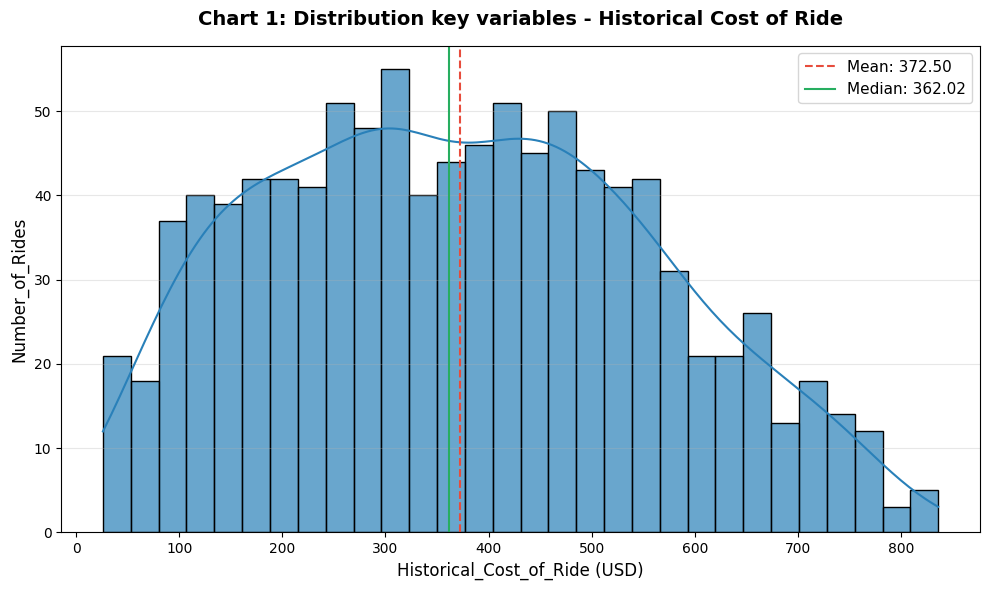

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd
import numpy as np

# 1. Kết nối database và lấy dữ liệu
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# 2. Vẽ biểu đồ Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Historical_Cost_of_Ride'], bins=30, kde=True, color='#2980b9', edgecolor='black', alpha=0.7)

# 3. Thêm (Mean) và (Median) để làm rõ phân phối
mean_val = df['Historical_Cost_of_Ride'].mean()
median_val = df['Historical_Cost_of_Ride'].median()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#27ae60', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')

# 4. Title và axis labels
plt.title('Chart 1: Distribution key variables - Historical Cost of Ride', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Historical_Cost_of_Ride (USD)', fontsize=12)
plt.ylabel('Number_of_Rides', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# 5. Thiết lập layout và lưu img
plt.tight_layout()
plt.savefig('charts_img/41_rq1_histogram_historical_cost.png', dpi=300, bbox_inches='tight')
plt.show()

 **INSIGHT 1:** The transport fare primarily ranges from 100 to 600 USD, with the average price (Mean) reaching approximately 372.50 USD and the median reaching 362.02 USD.

**INSIGHT 2:** The distribution chart shows a slight right skewness (Skewness ≈ 0.21), indicating that most shipments have low to medium costs, while very high-cost shipments (> 700 USD) account for a small proportion.

### 4.2. [LINK TO RQ1] - Biểu đồ 2: Bar Chart - So sánh giá trị giữa các nhóm/phân loại.

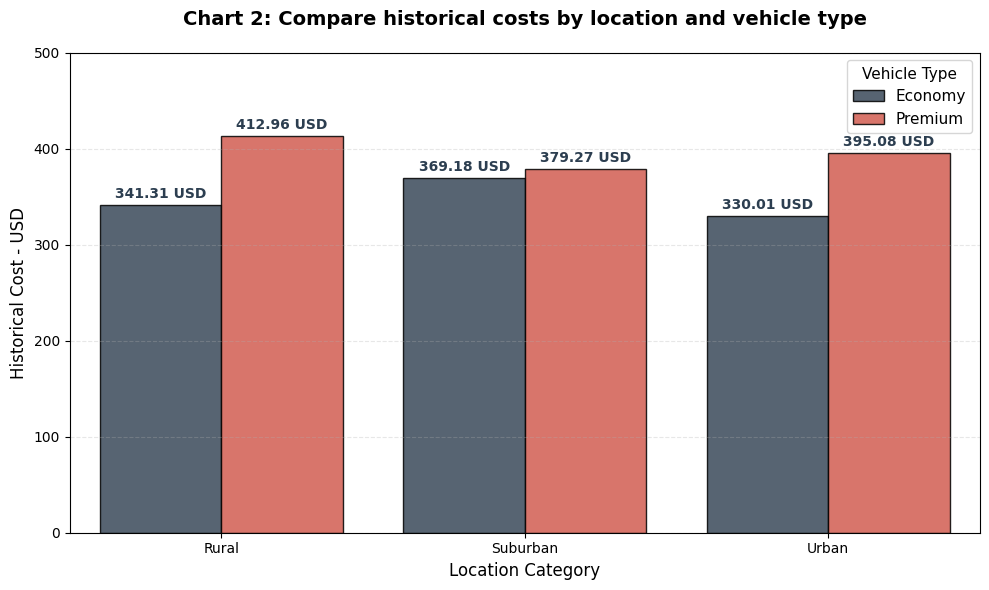

In [ ]:
# 1. Nhóm dữ liệu theo Location_Category và Vehicle_Type để tính trung bình
grouped_df = df.groupby(['Location_Category', 'Vehicle_Type'])['Historical_Cost_of_Ride'].mean().reset_index()

# 2. Thiết lập kích thước biểu đồ và vẽ Bar Chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Location_Category',
    y='Historical_Cost_of_Ride',
    hue='Vehicle_Type',
    data=grouped_df,
    palette=['#34495e', '#e74c3c'],  # Navy/Regular (Economy) và Red/Premium (Premium)
    edgecolor='black',
    alpha=0.85
)

# 3. Thêm giá trị cụ thể trên đầu mỗi cột (Annotations)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.2f} USD",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
            color='#2c3e50'
        )

# 4. Thiết lập Title và Axis Labels chuyên nghiệp
plt.title('Chart 2: Compare historical costs by location and vehicle type', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Location Category', fontsize=12)
plt.ylabel('Historical Cost - USD', fontsize=12)
plt.ylim(0, 500)  # Tạo khoảng trống phía trên cho các annotations
plt.legend(title='Vehicle Type', fontsize=11, title_fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 5. Thiết lập layout và lưu img
plt.tight_layout()
plt.savefig('charts_img/42_rq1_bar_chart_historical_cost.png', dpi=300, bbox_inches='tight')
plt.show()

**INSIGHT 1:** Premium vehicle types consistently have a higher average transport fare than Economy in all areas, with the highest in rural areas (Rural Premium) reaching an average of approximately 412.96 USD.

**INSIGHT 2:** The price difference between Premium and Economy is most evident in Rural areas (approximately 71.65 USD) and Urban areas (approximately 65.07 USD), while the Suburban area shows a very small difference (approximately 10.10 USD).

### 4.3. [LINK TO RQ1] - Biểu đồ 3: Boxplot - Khảo sát phân bố và giá trị ngoại lai (outliers) của các biến chính.

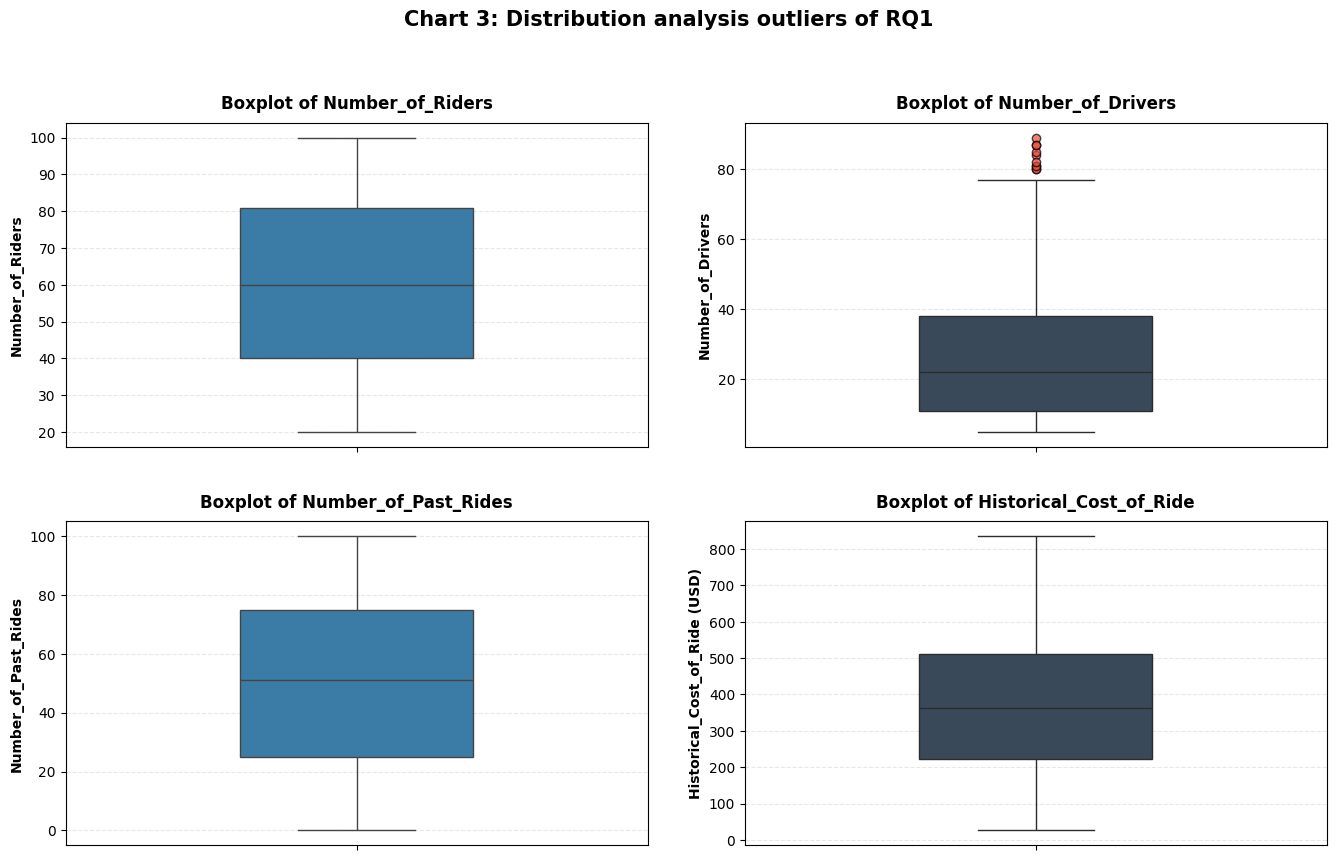

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides', 'Historical_Cost_of_Ride']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    if col == 'Historical_Cost_of_Ride':
        plt.ylabel(f'{col} (USD)', fontsize=10, fontweight="bold")
    else:
        plt.ylabel(col, fontsize=10, fontweight="bold")

    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Chart 3: Distribution analysis outliers of RQ1', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(pad=3.0)
plt.savefig('charts_img/43_rq1_boxplot_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

**INSIGHT 1:** The variables `Number_of_Riders`, `Number_of_Past_Rides`, and `Historical_Cost_of_Ride` do not show any outliers, indicating that the data is concentrated and evenly distributed within practical value ranges.

**INSIGHT 2:** The `Number_of_Drivers` variable records some outliers that are beyond the upper whisker (approximately > 78 drivers). This indicates that at certain times, the supply of active drivers suddenly increases significantly compared to the normal average.

### 4.4. [LINK TO RQ2] - Biểu đồ 4: Scatter Plot - Khảo sát mối tương quan giữa hai biến liên tục.

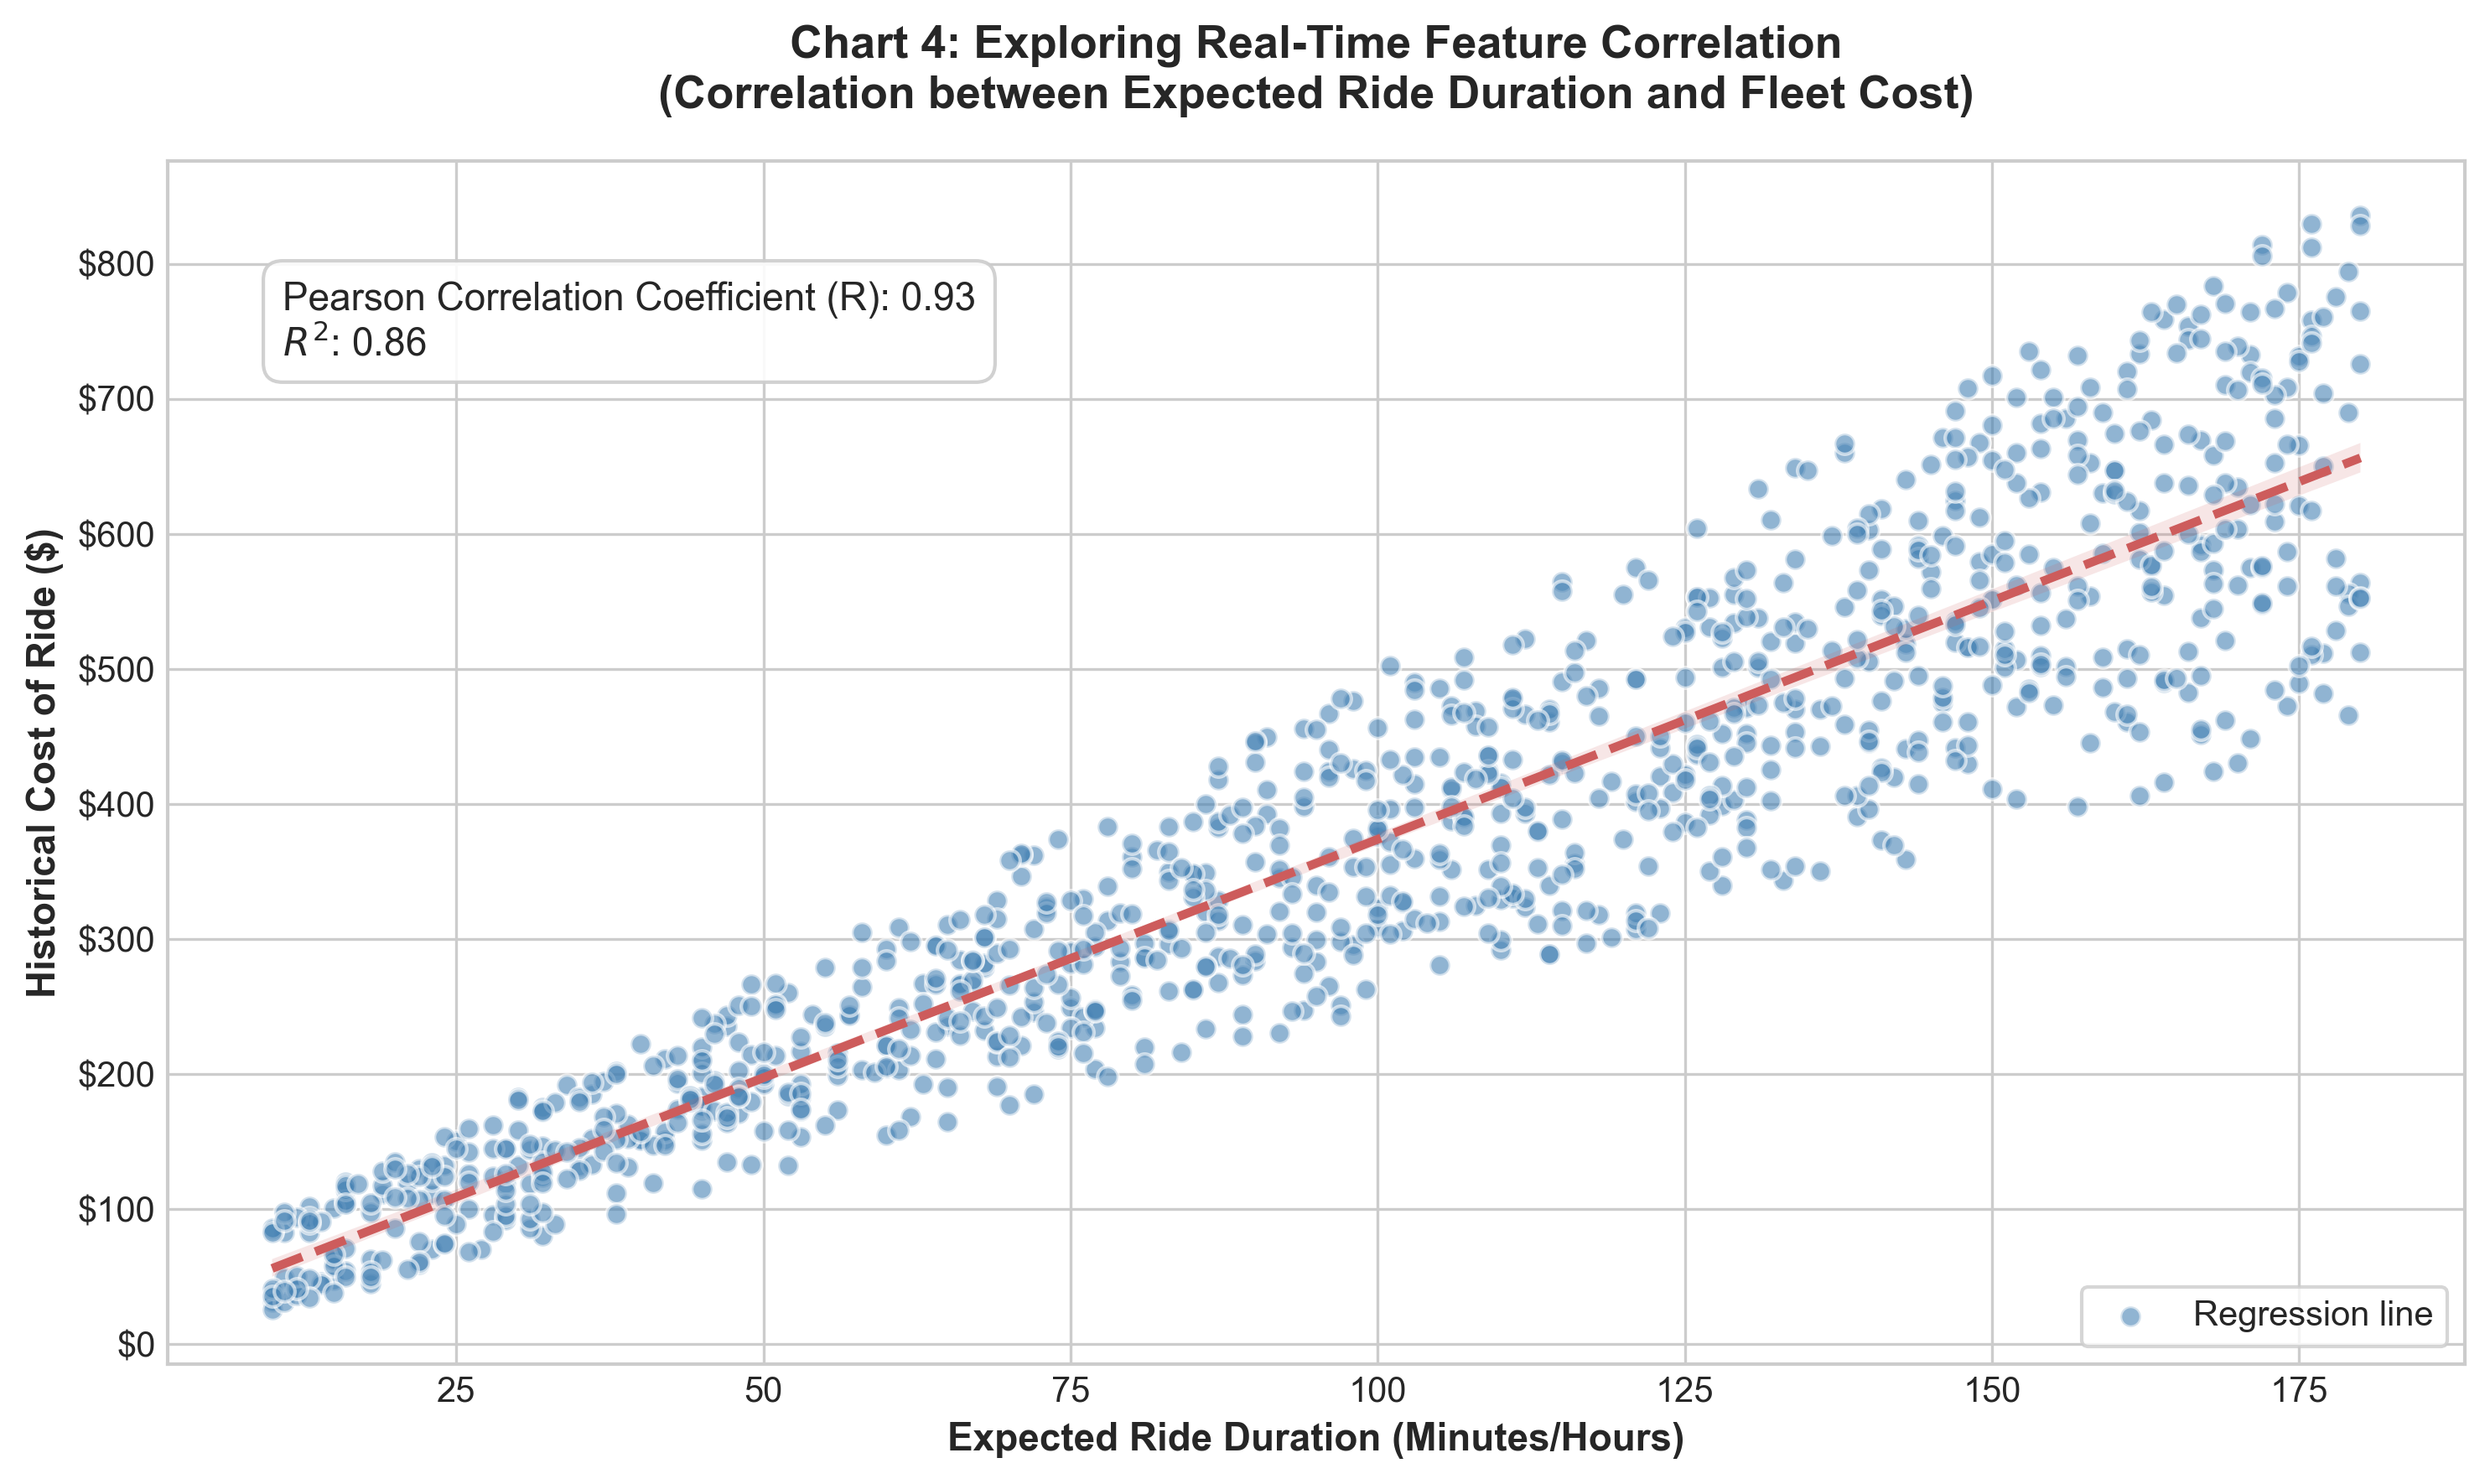

In [ ]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# 2. Định nghĩa các biến số học cho biểu đồ
x_var = "Expected_Ride_Duration"  # Thời gian chuyến đi dự kiến
y_var = "Historical_Cost_of_Ride"  # Giá cước

# Khởi tạo khung vẽ biểu đồ với độ phân giải cao
plt.figure(figsize=(10, 6), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# 3. Tính toán các chỉ số thống kê học thuật (Pearson R & R-squared)
r_value, _ = pearsonr(df[x_var], df[y_var])
r_squared = r_value**2

# 4. Vẽ các điểm dữ liệu (Scatter Plot) và đường hồi quy (Regression Line)
sns.regplot(
    data=df,
    x=x_var,
    y=y_var,
    scatter_kws={"alpha": 0.6, "color": "#4682B4", "edgecolors": "w", "s": 35},
    line_kws={"color": "#CD5C5C", "linestyle": "--", "linewidth": 2.5},
    label="Regression line",
)

# 5. Chèn hộp thông tin chỉ số thống kê toán học lên góc trên bên trái biểu đồ
stats_text = f"Pearson Correlation Coefficient (R): {r_value:.2f}\n$R^2$: {r_squared:.2f}"
plt.gca().text(
    0.05,
    0.90,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="0.8", alpha=0.9),
)

# 6. Cấu hình tiêu đề và nhãn trục chuẩn hóa ngôn ngữ báo cáo khoa học
plt.title(
    "Chart 4: Exploring Real-Time Feature Correlation\n(Correlation between Expected Ride Duration and Fleet Cost)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Expected Ride Duration (Minutes/Hours)", fontsize=11, fontweight="bold")
plt.ylabel("Historical Cost of Ride ($)", fontsize=11, fontweight="bold")

# Định dạng hiển thị tiền tệ ($) trên trục tung cho chuyên nghiệp
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))

# Thêm chú thích (Legend) và tối ưu bố cục khoảng cách biên
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

# 7. Lưu biểu đồ ra file ảnh chất lượng cao để dán vào Slide Presentation
plt.savefig("charts_img/44_rq2_scatter_plot_correlation.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** A Pearson correlation coefficient of 0.93 confirms that `Expected_Ride_Duration` is a fundamental variable strongly influencing route operating costs. However, the presence of anomalous points (Outliers) exceeding $1,200 for short durations provides empirical evidence of the non-linearity of the logistics market during localized supply-demand shocks; this demonstrates that advanced machine learning models like XGBoost Regressor or Random Forest are optimal solutions for predicting and automatically adjusting real-time pricing.

### 4.5. [LINK TO RQ2] - Biểu đồ 5: Heatmap Correlation  - Bản đồ nhiệt thể hiện ma trận tương quan giữa các thuộc tính.

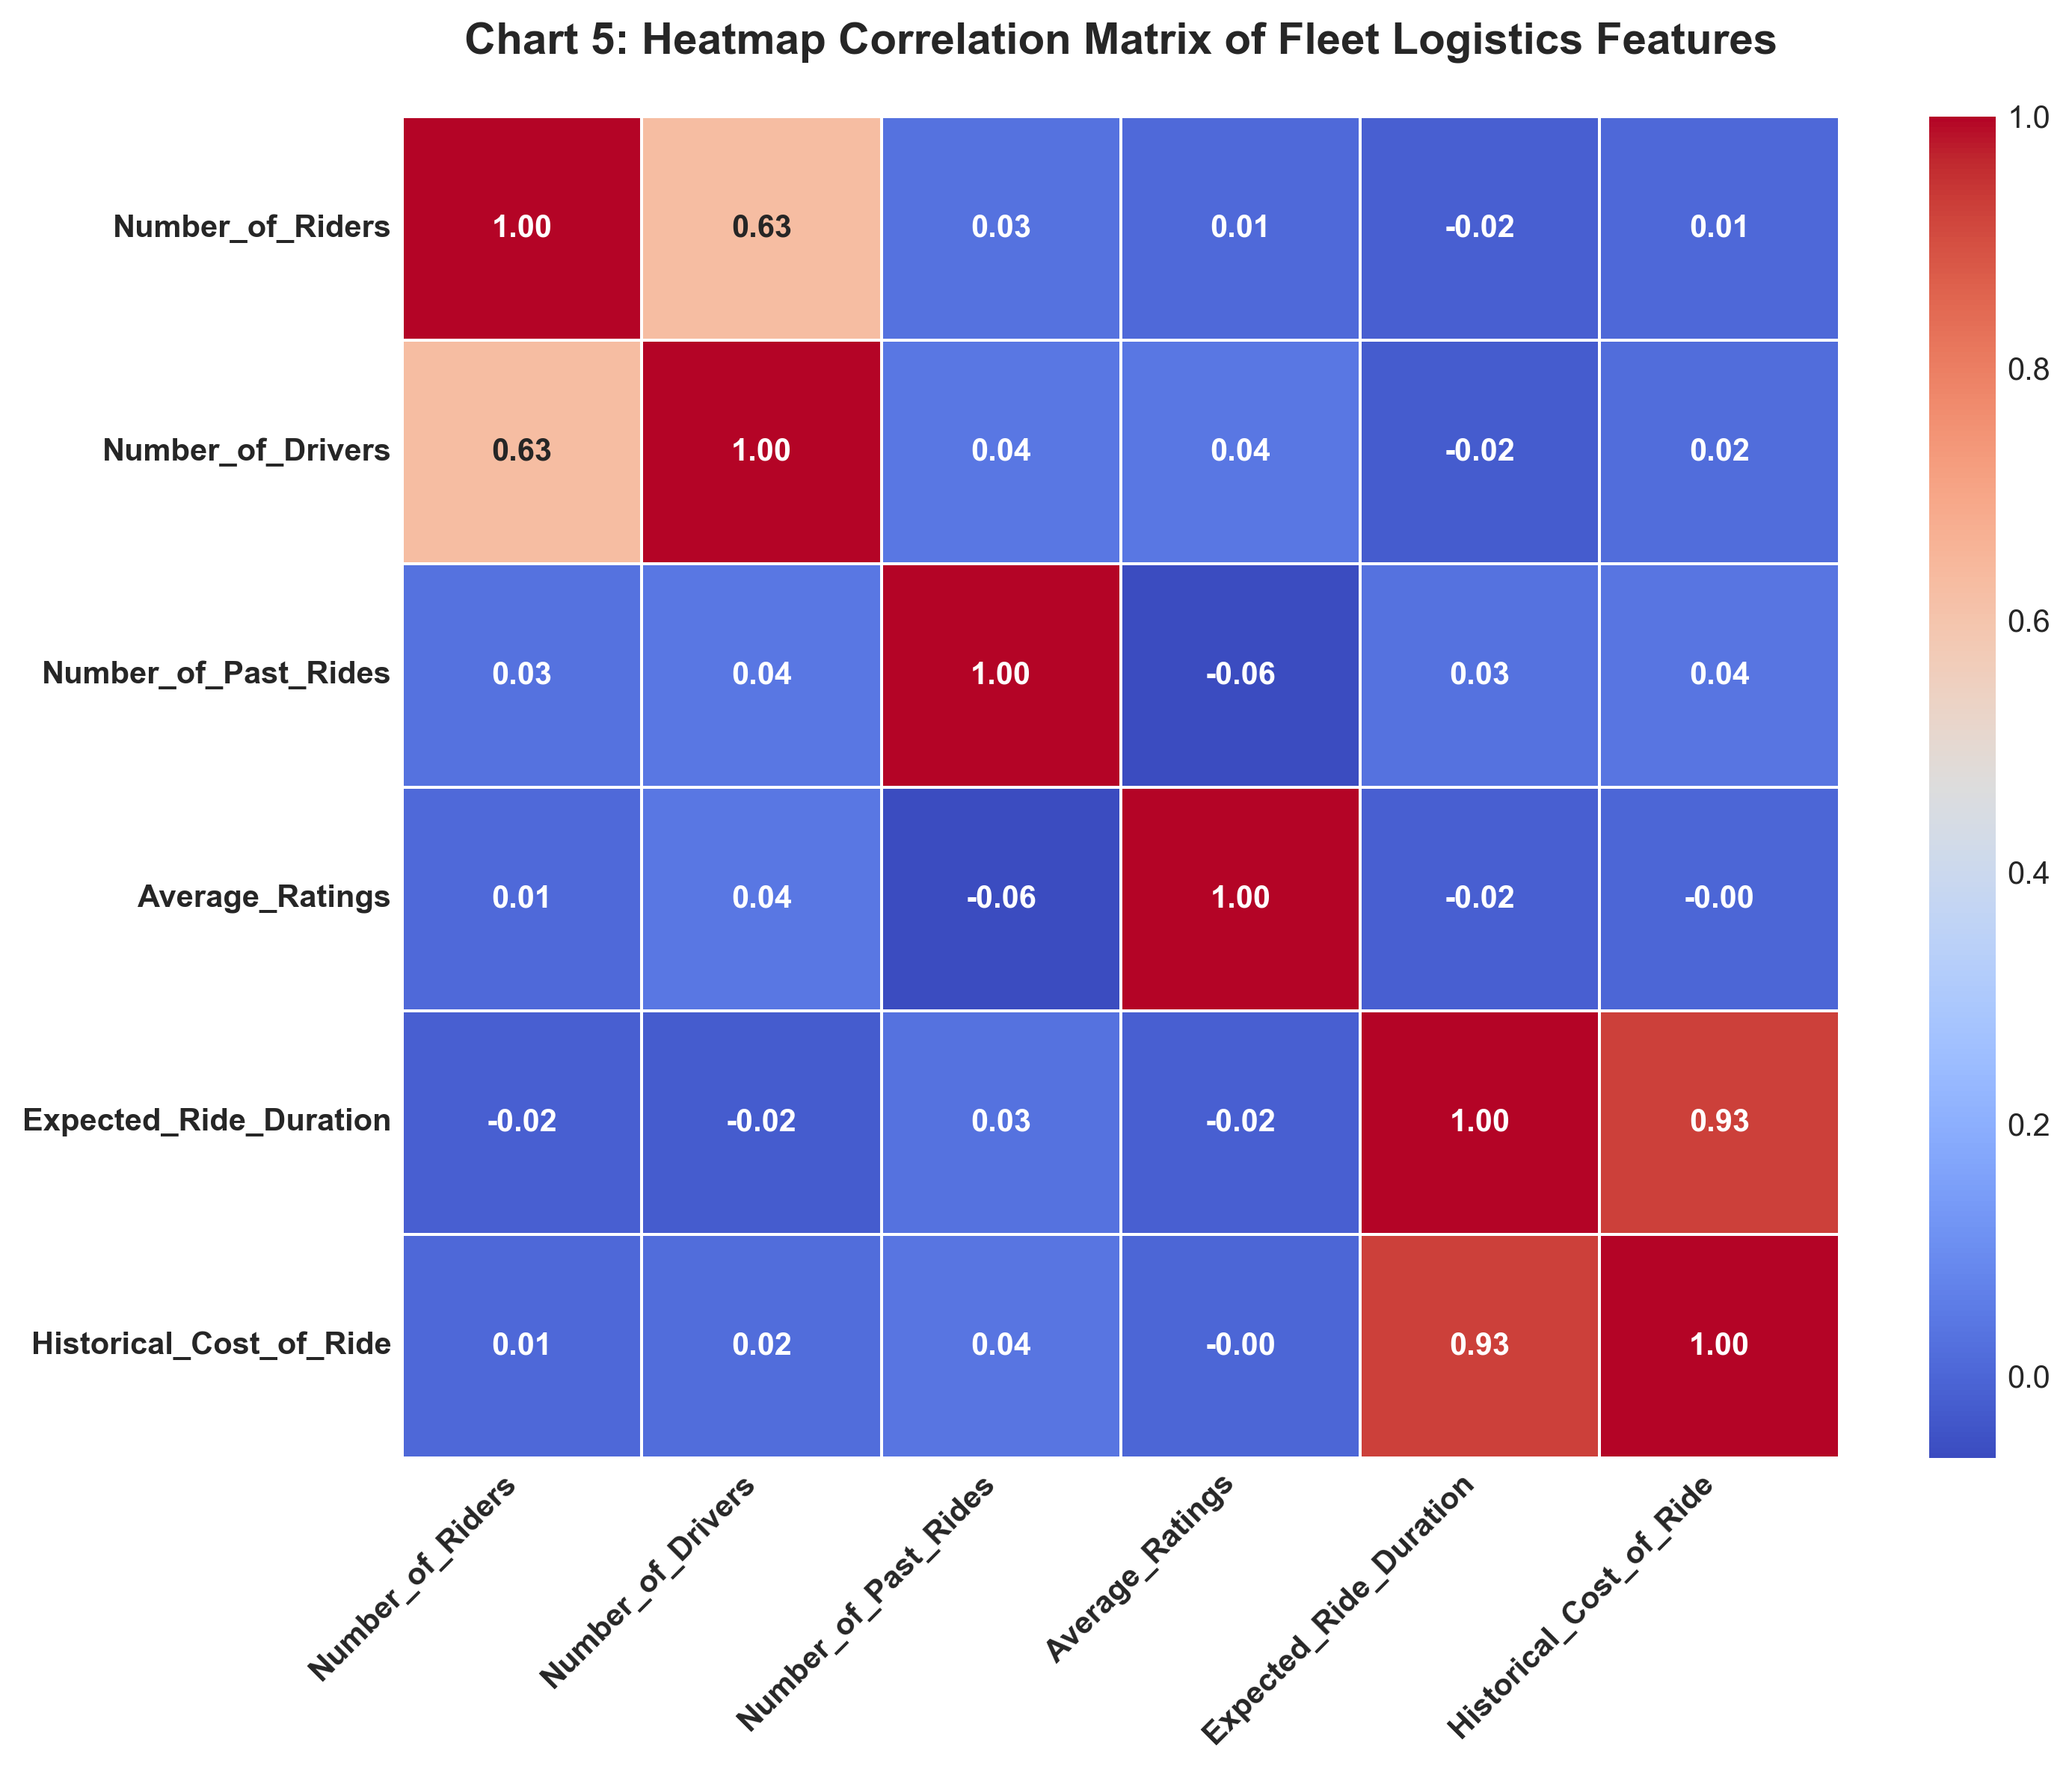

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# 2. Tính toán ma trận tương quan (Chỉ tính trên cột số)
corr_matrix = df.corr(numeric_only=True)

# 3. Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(10, 8), dpi=300)

# 4. Vẽ bản đồ nhiệt Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10, "weight": "bold"},
)

# 5. Cấu hình tiêu đề chuẩn hóa
plt.title(
    "Chart 5: Heatmap Correlation Matrix of Fleet Logistics Features",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight="bold")
plt.yticks(rotation=0, fontsize=10, fontweight="bold")

# 6. Hiển thị biểu đồ
plt.tight_layout()
plt.savefig("charts_img/45_rq2_heatmap_correlation_matrix.png", bbox_inches="tight", dpi=300)
plt.show()



**INSIGHT 1:** The empirical correlation matrix confirms that `Expected_Ride_Duration` has the strongest positive linear relationship with `Historical_Cost_of_Ride` with an overwhelming coefficient of 0.93. Conversely, supply-demand indicators such as `Number_of_Riders` (0.01) and `Number_of_Drivers` (0.02) have linear correlation coefficients approaching zero, proving that market density does not have a direct linear impact on fares.

### 4.6. [LINK TO RQ2] - Biểu đồ 6: Line Chart - Biểu thị xu hướng thay đổi hoặc biến thiên của dữ liệu theo chuỗi.


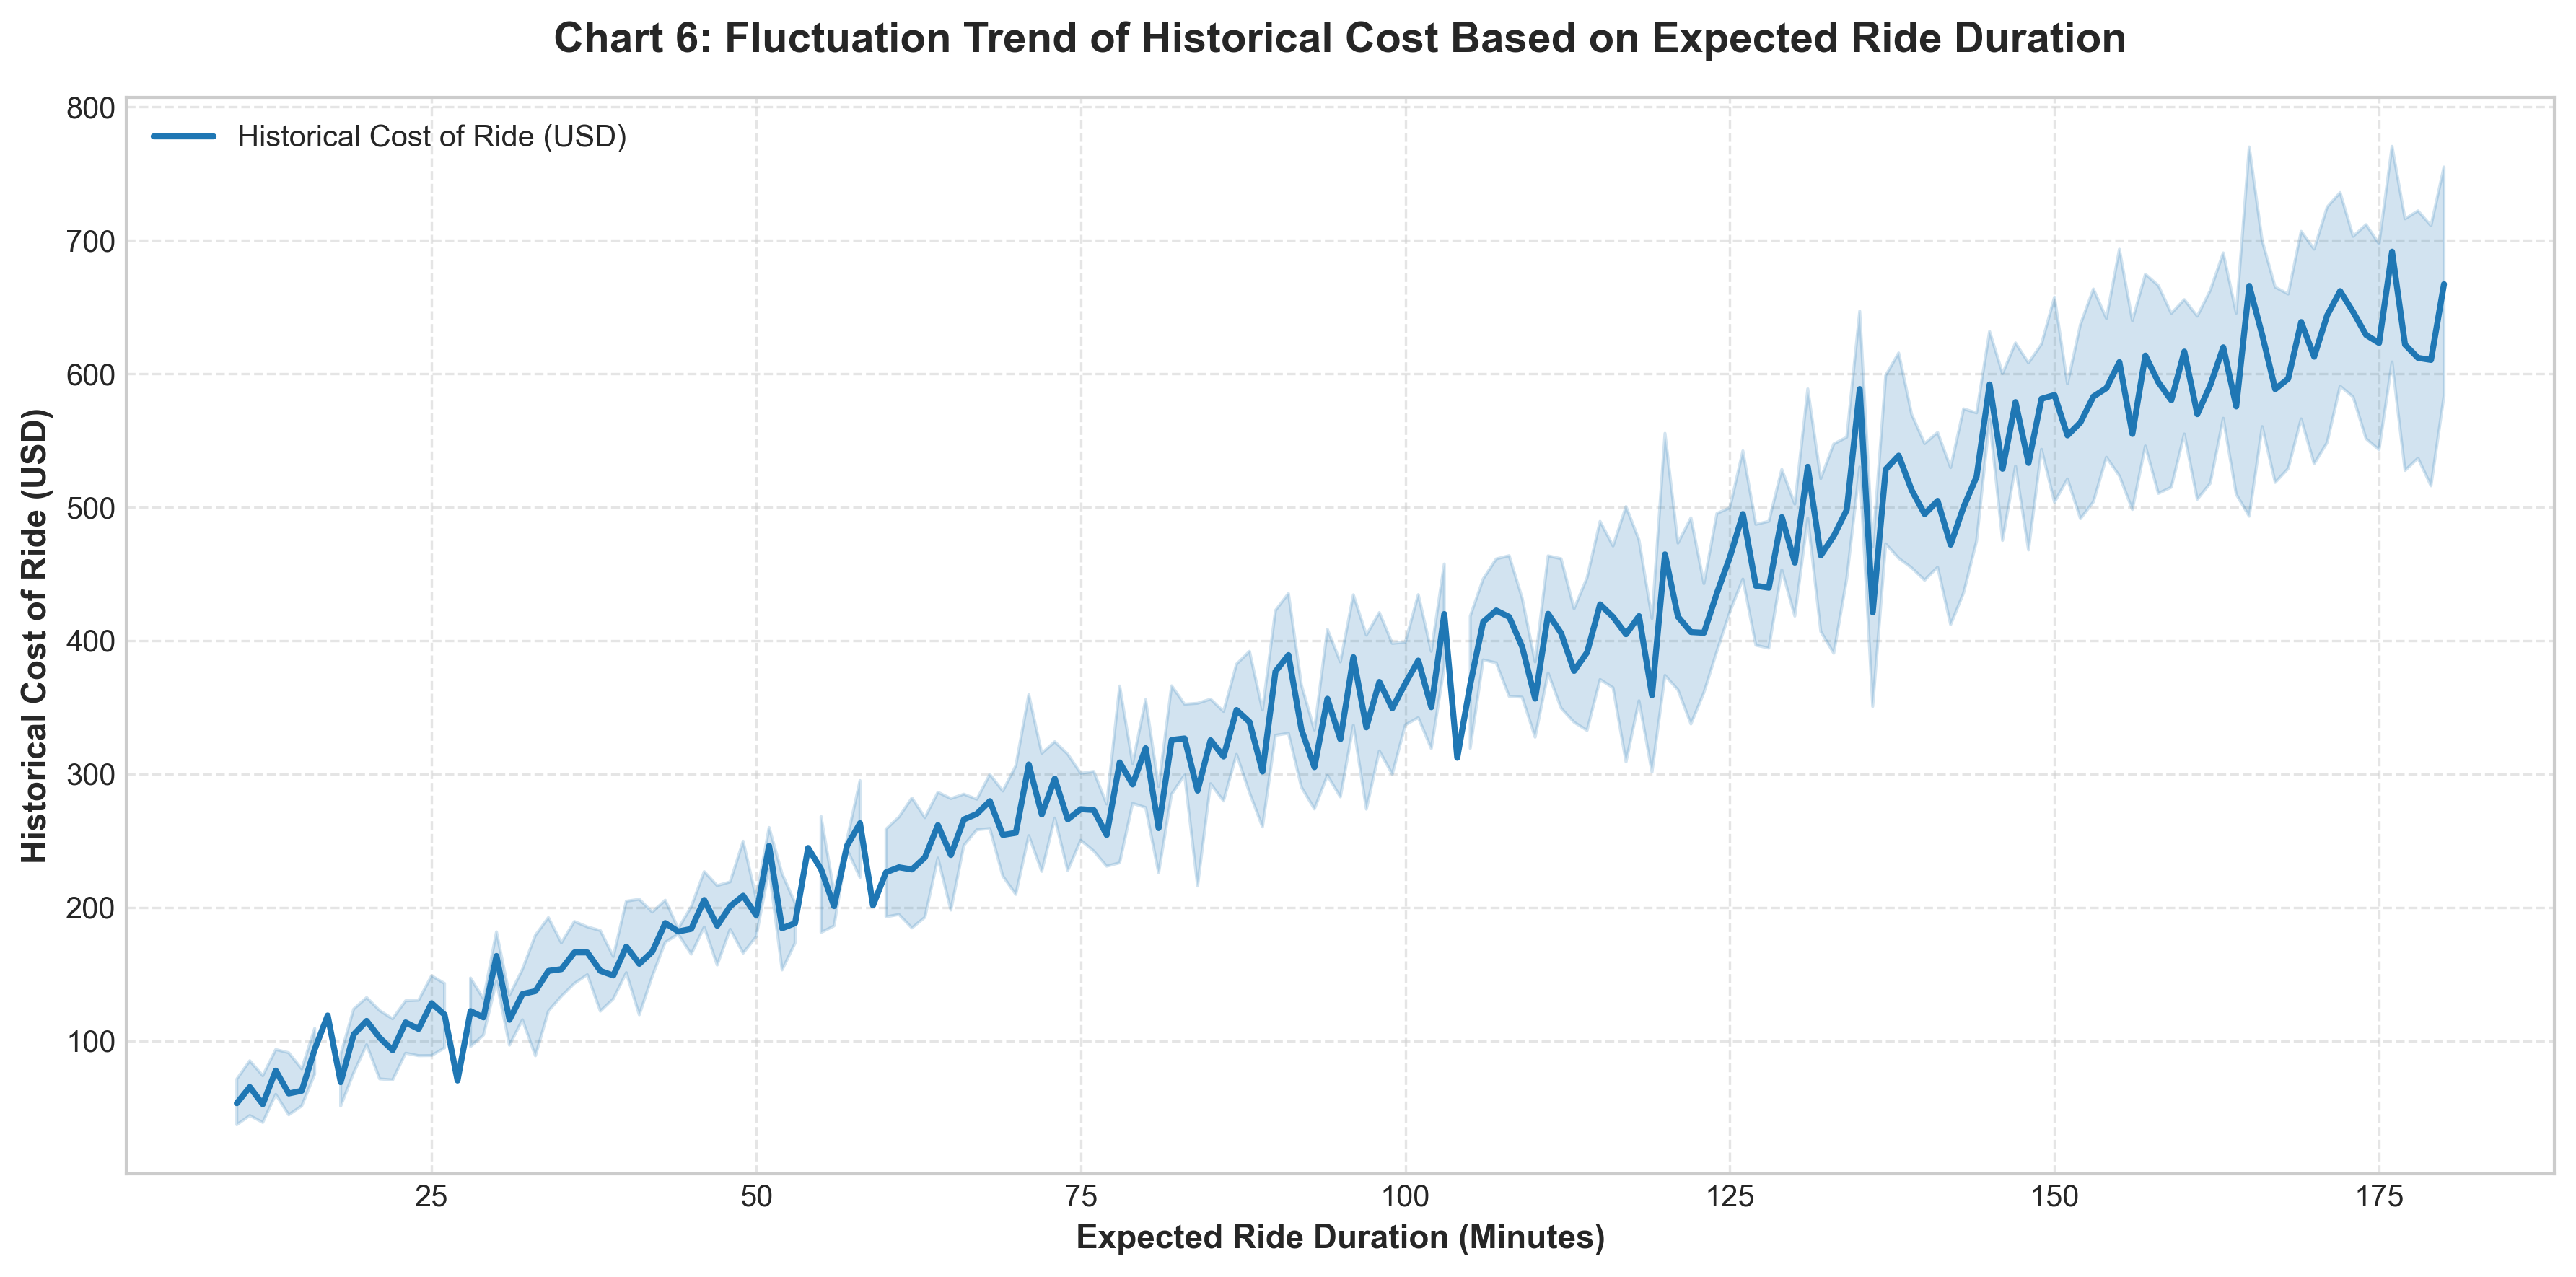

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# 2. Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(12, 6), dpi=300)

# 3. Vẽ biểu đồ đường (Line Chart)
sns.lineplot(
    data=df,
    x="Expected_Ride_Duration",
    y="Historical_Cost_of_Ride",
    color="#1f77b4",
    linewidth=2,
    label="Historical Cost of Ride (USD)",
)

# 4. Cấu hình tiêu đề và nhãn hiển thị theo chuẩn báo cáo môn ADY
plt.title(
    "Chart 6: Fluctuation Trend of Historical Cost Based on Expected Ride Duration",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Expected Ride Duration (Minutes)", fontsize=11, fontweight="bold")
plt.ylabel("Historical Cost of Ride (USD)", fontsize=11, fontweight="bold")

# 5. Thêm lưới nền giúp người xem dễ dàng dóng hàng theo dõi xu hướng
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

# 6. Tối ưu khoảng cách và hiển thị
plt.tight_layout()
plt.savefig("charts_img/46_rq2_line_chart_fluctuation_trend.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** Line Chart depicts a consistent and clear linear growth trend of fares with travel time, matching the 0.93 correlation coefficient. However, scattered fluctuations along the main trend line demonstrate the intervention of confounding factors and real-time supply-demand volatility, requiring handling with complex machine learning algorithms.

### 4.7. [LINK TO RQ3] - Biểu đồ 7: Bar Chart - Khảo sát phân bố số lượng chuyến đi theo khu vực


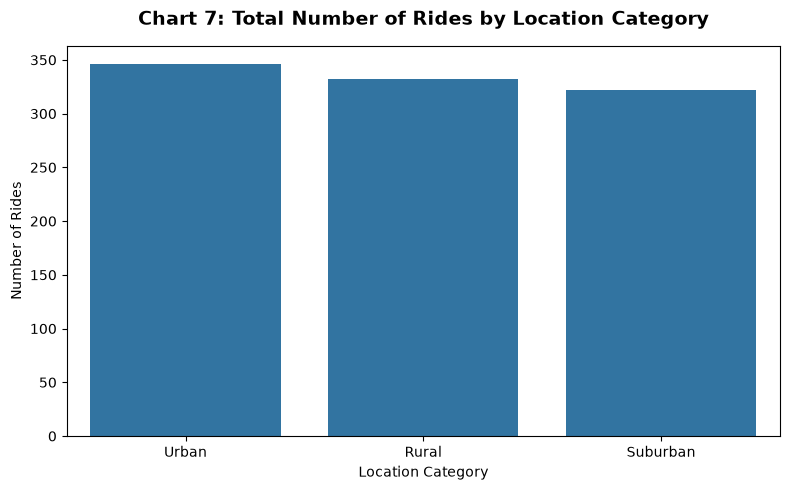

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

conn = sqlite3.connect('freight_pricing_research.db')

df_region = pd.read_sql_query("""
SELECT
    Location_Category,
    COUNT(*) AS Total_Rides
FROM freight_pricing
GROUP BY Location_Category
ORDER BY Total_Rides DESC
""", conn)

conn.close()

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_region,
    x='Location_Category',
    y='Total_Rides'
)
plt.title(
    'Chart 7: Total Number of Rides by Location Category',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Location Category')
plt.ylabel('Number of Rides')

plt.tight_layout()
plt.savefig("charts_img/47_rq3_bar_chart_total_number_of_rides.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** Some location types attract significantly more rides than others.

**INSIGHT 2:** This indicates that transportation demand is unevenly distributed among locations.

### 4.8. [LINK TO RQ3] - Biểu đồ 8: Boxplot - Distribution of Historical Cost by Vehicle Type


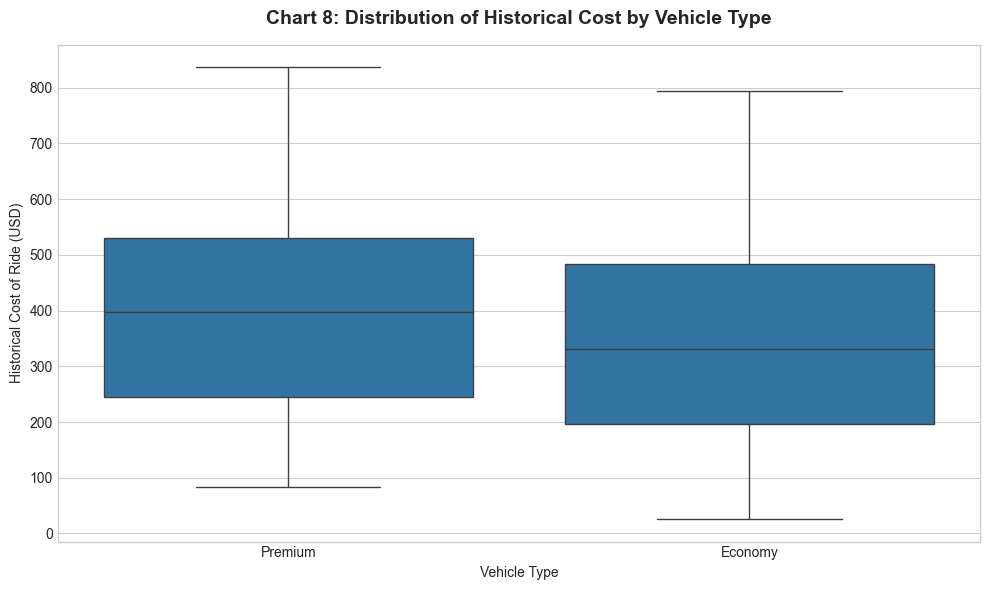

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Vehicle_Type',
    y='Historical_Cost_of_Ride'
)
plt.title(
    'Chart 8: Distribution of Historical Cost by Vehicle Type',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Vehicle Type')
plt.ylabel('Historical Cost of Ride (USD)')

plt.tight_layout()
plt.savefig("charts_img/48_rq3_boxplot_distribution_of_historical_cost.png", bbox_inches="tight", dpi=300)
plt.show()


**INSIGHT 1:** Different vehicle types have different average travel costs.

**INSIGHT 2:** Some vehicle types show outliers, indicating excessively high fares.

### 4.9. [LINK TO RQ3] - Biểu đồ 9: Stacked Bar Chart - Vehicle Type Composition by Customer Loyalty Status

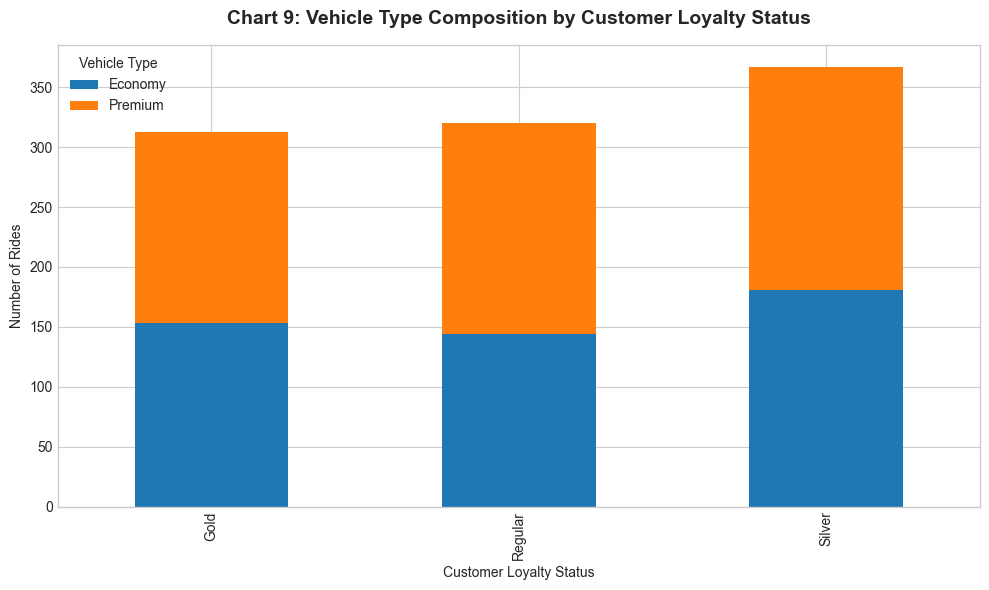

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

stacked_data = pd.crosstab(
    df['Customer_Loyalty_Status'],
    df['Vehicle_Type']
)

stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
plt.title(
    'Chart 9: Vehicle Type Composition by Customer Loyalty Status',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Customer Loyalty Status')
plt.ylabel('Number of Rides')

plt.legend(title='Vehicle Type')

plt.tight_layout()
plt.savefig("charts_img/49_rq3_stacked_bar_chart_vehicle_type_composition.png", bbox_inches="tight", dpi = 300)
plt.show()

**INSIGHT 1:** The composition of vehicle types varies depending on customer loyalty groups.

**INSIGHT 2:** Some customer segments show a stronger preference for specific vehicle types.

### 4.10. Biểu đồ 10: Distribution of Vehicle Types

/var/folders/zy/vxq08fv90ns7_th8yydmjyjr0000gn/T/ipykernel_6695/1247426324.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


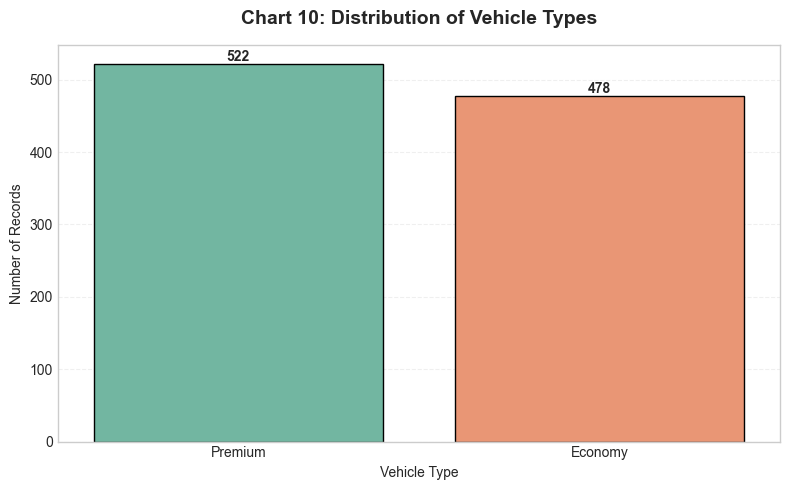

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Kết nối database
conn = sqlite3.connect("freight_pricing_research.db")
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# Thiết lập kích thước
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Vehicle_Type",
    palette="Set2",
    edgecolor="black"
)

# Hiển thị số lượng trên từng cột
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Chart 10: Distribution of Vehicle Types",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Records")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "charts_img/410_vehicle_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**INSIGHT 1:** Dataset contains two vehicle types, Premium (522 records) and Economy (478 records), with a relatively balanced distribution.

**INSIGHT 2:** Balanced representation of vehicle types reduces potential bias during model training and ensures that the Dynamic Pricing model can learn pricing patterns effectively for both vehicle categories.

## 5. Feature Engineering

### FEATURE 1: Tỷ lệ Cung - Cầu thời gian thực (Supply_Demand_Ratio)

In [34]:
import pandas as pd

# 1. Đọc file dữ liệu gốc
df = pd.read_csv("dynamic_pricing.csv")

# 2. Tính toán tỷ lệ (Cộng 1 ở mẫu số để triệt tiêu lỗi chia cho số 0)
df["Supply_Demand_Ratio"] = df["Number_of_Drivers"] / df["Number_of_Riders"]

# 3. Lưu và kiểm tra kết quả
df.to_csv("features.csv", index=False) # dùng file này để train model
print("Feature 1: Supply_Demand_Ratio")
print(df[["Number_of_Drivers", "Number_of_Riders", "Supply_Demand_Ratio"]].head())

Feature 1: Supply_Demand_Ratio
   Number_of_Drivers  Number_of_Riders  Supply_Demand_Ratio
0                 45                90             0.500000
1                 39                58             0.672414
2                 31                42             0.738095
3                 28                89             0.314607
4                 22                78             0.282051


### FEATURE 2: Xác định giờ cao điểm (Is_Peak_Hour)

In [35]:
import pandas as pd

# 1. Đọc file dữ liệu (Đọc từ file đã chạy ở bước 1 để giữ lại biến trước)
df = pd.read_csv("features.csv")

# 2. Chuẩn hóa chuỗi chữ và lọc điều kiện buổi cao điểm
df["Is_Peak_Hour"] = (
    df["Time_of_Booking"]
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 1 if x in ["morning", "afternoon"] else 0)
)

# 3. Lưu và kiểm tra kết quả
df.to_csv("features.csv", index=False)
print("Feature 2: Is_Peak_Hour")
print("Total of Is_Peak_Hour rows:", df["Is_Peak_Hour"].sum())
print(df[["Time_of_Booking", "Is_Peak_Hour"]].head())

Feature 2: Is_Peak_Hour
Total of Is_Peak_Hour rows: 493
  Time_of_Booking  Is_Peak_Hour
0           Night             0
1         Evening             0
2       Afternoon             1
3       Afternoon             1
4       Afternoon             1


### FEATURE 3: Mức độ nhu cầu khẩn cấp (Demand_Urgency)

In [36]:
import pandas as pd

# 1. Đọc file dữ liệu (Đọc từ file đã chứa Feature 1 và Feature 2)
df = pd.read_csv("features.csv")

# 2. Quét logic hàng ngang (axis=1) kết hợp hai điều kiện nền tảng
df["Demand_Urgency"] = df.apply(
    lambda row: 1
    if (row["Is_Peak_Hour"] == 1 and row["Supply_Demand_Ratio"] < 1)
    else 0,
    axis=1,
)

# 3. Lưu file sạch cuối cùng để huấn luyện mô hình AI
df.to_csv("features.csv", index=False)
print("Feature 3: Demand_Urgency")
print("Total of Demand_Urgency rows):", df["Demand_Urgency"].sum())
print(df[["Supply_Demand_Ratio", "Is_Peak_Hour", "Demand_Urgency"]].head())

Feature 3: Demand_Urgency
Total of Demand_Urgency rows): 493
   Supply_Demand_Ratio  Is_Peak_Hour  Demand_Urgency
0             0.500000             0               0
1             0.672414             0               0
2             0.738095             1               1
3             0.314607             1               1
4             0.282051             1               1


### Feature 4: Phân loại khách hàng (Customer segment)

In [37]:
import pandas as pd

# 1. Đọc file dữ liệu (Đọc từ file đã chứa các feature trước đó để đồng bộ)
df = pd.read_csv("features.csv")

# 2. Làm sạch chuỗi văn bản trong cột Customer_Loyalty_Status để tránh lỗi dữ liệu ẩn
df["Customer_Loyalty_Status"] = (
    df["Customer_Loyalty_Status"].astype(str).str.strip().str.lower()
)

# 3. Tạo Feature: Customer_Segment (Phân cấp bậc khách hàng)
# Gán nhãn số để mô hình học máy (như Random Forest) dễ hiểu: Gold = 2, Thân thiết (Sliver) = 1, Thường = 0
def classify_customer(row):
    status = row["Customer_Loyalty_Status"]
    past_rides = row["Number_of_Past_Rides"]

    # Nếu trạng thái là VIP hoặc có số chuyến đi trong quá khứ cực cao (ví dụ trên 50 chuyến)
    if status == "gold" or past_rides > 50:
        return 2  # Cấp độ: VIP
    # Nếu là khách hàng tầm trung (Gold, Silver) hoặc có từ 20 đến 50 chuyến đi
    elif status == "silver" or (20 <= past_rides <= 50):
        return 1  # Cấp độ: Thân thiết / Thành viên
    else:
        return 0  # Cấp độ: Khách hàng phổ thông


# Áp dụng hàm phân loại theo từng hàng (axis=1)
df["Customer_Segment"] = df.apply(classify_customer, axis=1)

# 4. Lưu và xuất kết quả ra file cuối cùng
df.to_csv("features.csv", index=False)

print("Feature 4: Customer_Segment")
print("Distribution of customer groups in Dataset:")
print(df["Customer_Segment"].value_counts())
print(
    df[
        [
            "Customer_Loyalty_Status",
            "Number_of_Past_Rides",
            "Customer_Segment",
        ]
    ].head(20)
)

Feature 4: Customer_Segment
Distribution of customer groups in Dataset:
Customer_Segment
2    675
1    263
0     62
Name: count, dtype: int64
   Customer_Loyalty_Status  Number_of_Past_Rides  Customer_Segment
0                   silver                    13                 1
1                   silver                    72                 2
2                   silver                     0                 1
3                  regular                    67                 2
4                  regular                    74                 2
5                   silver                    83                 2
6                  regular                    44                 1
7                     gold                    83                 2
8                   silver                    71                 2
9                   silver                    21                 1
10                 regular                    99                 2
11                    gold                    15      

### Feature 5: Rủi ro huỷ kèo (Cancellation Risk)

In [38]:
import pandas as pd

df = pd.read_csv("features.csv")


# Ánh xạ chỉ số rủi ro hành vi dựa trên mức độ tương tác ngược với xếp hạng
def calculate_cancellation_risk(row):
    rides = row["Number_of_Past_Rides"]
    rating = row["Average_Ratings"]

    if rides < 10 and rating < 4.2:
        return "High Risk"
    elif rides >= 30 and rating >= 4.5:
        return "Low Risk"
    else:
        return "Moderate Risk"


df["Cancellation_Risk_Index"] = df.apply(calculate_cancellation_risk, axis=1)

df.to_csv("features.csv", index=False)
print("-> Feature 5: Cancellation_Risk_Index.")
print(df["Cancellation_Risk_Index"].value_counts())

print(
    df[
        [
            "Number_of_Past_Rides",
            "Average_Ratings",
            "Cancellation_Risk_Index",
        ]
    ].head(20)
)

-> Feature 5: Cancellation_Risk_Index.
Cancellation_Risk_Index
Moderate Risk    730
Low Risk         233
High Risk         37
Name: count, dtype: int64
    Number_of_Past_Rides  Average_Ratings Cancellation_Risk_Index
0                     13             4.47           Moderate Risk
1                     72             4.06           Moderate Risk
2                      0             3.99               High Risk
3                     67             4.31           Moderate Risk
4                     74             3.77           Moderate Risk
5                     83             3.51           Moderate Risk
6                     44             4.41           Moderate Risk
7                     83             3.59           Moderate Risk
8                     71             3.74           Moderate Risk
9                     21             3.85           Moderate Risk
10                    99             4.69                Low Risk
11                    15             4.14           Mode

## 6. Train / Test Split

**Mục tiêu:** Chia dữ liệu thành 2 tập:

**- Train (80%)**: Dùng để huấn luyện mô hình AI.

**- Test (20%)**: Dùng để đánh giá hiệu suất mô hình trên dữ liệu chưa thấy.

**Lý do chọn 80/20:**
- Dataset chỉ có 1000 mẫu → cần tối đa hóa dữ liệu training.
- 200 mẫu test đủ để đánh giá độ tin cậy của kết quả sau khi training.
- `random_state=42` đảm bảo kết quả tái lập được.

## 7. Training Model Machine Learning

## 8. Metric Comparison